In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
np.set_printoptions(suppress=True)

print("Wagi przed skalowaniem: ")

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

Wagi przed skalowaniem: 


# Decision Tree Classification Model - Sleep Health Dataset
# Wytrenowanie modelu klasyfikacyjnego do przewidywania zmiennej 'felt_rested'
# na podstawie zbioru sleep_health_dataset.csv


## WCZYTANIE I EKSPLORACJA DANYCH


In [2]:
file_path = "../resources/sleep_health_dataset.csv"
df = pd.read_csv(file_path)

if 'person_id' in df.columns:
    df = df.drop('person_id', axis=1)

print(f"\nRozmiar calego zbioru danych: {df.shape[0]} wierszy x {df.shape[1]} kolumn\n")

df.info()
df.describe().round(2)


Rozmiar calego zbioru danych: 100000 wierszy x 31 kolumn

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   gender                       100000 non-null  str    
 2   occupation                   100000 non-null  str    
 3   bmi                          100000 non-null  float64
 4   country                      100000 non-null  str    
 5   sleep_duration_hrs           100000 non-null  float64
 6   sleep_quality_score          100000 non-null  float64
 7   rem_percentage               100000 non-null  float64
 8   deep_sleep_percentage        100000 non-null  float64
 9   sleep_latency_mins           100000 non-null  int64  
 10  wake_episodes_per_night      100000 non-null  int64  
 11  caffeine_mg_before_bed       100000 non-null  int64  
 12  alcohol_uni

,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,...,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,34.71,26.29,6.42,4.87,20.24,20.25,19.84,3.35,38.85,0.60,...,14.94,5.73,7.13,66.57,0.56,0.08,20.54,1.20,59.23,0.39
std,11.04,4.48,1.27,1.51,3.41,4.25,7.58,1.92,69.40,1.06,...,21.39,1.62,3.48,7.23,0.50,0.28,2.90,0.79,22.25,0.49
min,18.00,16.00,3.00,1.00,10.00,5.00,1.00,0.00,0.00,0.00,...,0.00,1.00,0.00,45.00,0.00,0.00,15.00,-1.00,0.00,0.00
25%,26.00,23.20,5.53,3.80,18.00,17.40,14.00,2.00,0.00,0.00,...,0.00,4.80,4.70,62.00,0.00,0.00,18.50,0.67,44.20,0.00
50%,33.00,26.30,6.36,4.90,20.30,20.30,19.00,3.00,0.00,0.00,...,0.00,5.80,7.40,67.00,1.00,0.00,20.50,1.20,60.40,0.00
75%,42.00,29.30,7.27,6.00,22.60,23.20,25.00,5.00,80.00,1.00,...,30.00,6.80,9.70,71.00,1.00,0.00,22.50,1.74,75.80,1.00
max,69.00,45.00,10.50,10.00,30.00,30.00,58.00,8.00,400.00,6.00,...,116.00,10.00,18.00,99.00,1.00,1.00,28.00,3.00,100.00,1.00


## PREPROCESSING DANYCH


In [3]:
categorical_cols = df.select_dtypes(include=['str']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nZmienne kategoryczne: {categorical_cols}")
print(f"Zmienne numeryczne: {numerical_cols}")


label_encoders = {}
df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"\nKodowanie {col}:")
    for i, class_name in enumerate(le.classes_):
        print(f"  {class_name} -> {i}")

df_encoded.head(5)


Zmienne kategoryczne: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk']
Zmienne numeryczne: ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'cognitive_performance_score', 'felt_rested']

Kodowanie gender:
  Female -> 0
  Male -> 1
  Other -> 2

Kodowanie occupation:
  Doctor -> 0
  Driver -> 1
  Freelancer -> 2
  Homemaker -> 3
  Lawyer -> 4
  Manager -> 5
  Nurse -> 6
  Retired -> 7
  Sales -> 8
  Software Engineer -> 9
  Student -> 10
  Teacher -> 11

Kodowanie country:
  Australia -> 0
  Brazil -> 1
  Canada -> 2
  France -

,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,29,0,1,25.7,7,6.19,6.6,22.5,19.3,16,...,63,0,0,20.1,1.84,0,0,73.4,0,0
1,55,0,9,22.0,14,8.32,6.9,26.9,14.9,17,...,52,1,0,18.0,0.13,3,1,99.4,0,1
2,42,1,6,25.0,5,3.74,1.0,20.2,16.2,26,...,72,0,1,17.9,1.67,1,1,2.5,3,0
3,37,0,10,29.5,5,6.79,6.4,17.7,17.7,13,...,71,0,0,19.1,2.37,2,1,67.8,0,0
4,23,1,4,23.6,11,5.02,3.2,23.3,18.3,30,...,71,0,0,19.7,1.26,2,0,38.1,1,0


In [4]:
target_col = 'felt_rested'
y = df_encoded[target_col]
X = df_encoded.drop(columns=[target_col])

print(f"\nZmienne niezalezne (cechy): {X.columns.tolist()}")
print(f"\nZmienna zalezna (target): {target_col}")
print(f"Klasy: {sorted(y.unique())}")
print(f"\nRozklad klas:")
print(y.value_counts())


Zmienne niezalezne (cechy): ['age', 'gender', 'occupation', 'bmi', 'country', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk']

Zmienna zalezna (target): felt_rested
Klasy: [np.int64(0), np.int64(1)]

Rozklad klas:
felt_rested
0    60988
1    39012
Name: count, dtype: int64


## PODZIAŁ NA ZBIÓR TRENINGOWY I TESTOWY


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=13
)

print(f"\nRozmiar zbioru treningowego: {X_train.shape[0]} wierszy x {X_train.shape[1]} kolumn")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]} wierszy x {X_test.shape[1]} kolumn")

print(f"\nRozklad klas w zbiorze treningowym:")
print(pd.Series(y_train).value_counts())
print(f"\nRozklad klas w zbiorze testowym:")
print(pd.Series(y_test).value_counts())



Rozmiar zbioru treningowego: 80000 wierszy x 30 kolumn
Rozmiar zbioru testowego: 20000 wierszy x 30 kolumn

Rozklad klas w zbiorze treningowym:
felt_rested
0    48787
1    31213
Name: count, dtype: int64

Rozklad klas w zbiorze testowym:
felt_rested
0    12201
1     7799
Name: count, dtype: int64


## TRENOWANIE MODELU DECISION TREE CLASSIFIER


In [6]:
dt_classifier = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=13,
    min_samples_split=10
)
dt_classifier.fit(X_train, y_train)

print(f"Glebokosc drzewa: {dt_classifier.get_depth()}")
print(f"Liczba lisci: {dt_classifier.get_n_leaves()}")


Glebokosc drzewa: 5
Liczba lisci: 32



Waznosc cech (Feature Importances):
                        feature  importance
6           sleep_quality_score    0.631041
5            sleep_duration_hrs    0.276701
10      wake_episodes_per_night    0.048881
17                 stress_score    0.039903
29          sleep_disorder_risk    0.001830
24     room_temperature_celsius    0.000686
7                rem_percentage    0.000554
28  cognitive_performance_score    0.000405
2                    occupation    0.000000
8         deep_sleep_percentage    0.000000
4                       country    0.000000
3                           bmi    0.000000
1                        gender    0.000000
0                           age    0.000000
13  screen_time_before_bed_mins    0.000000
12     alcohol_units_before_bed    0.000000
11       caffeine_mg_before_bed    0.000000
9            sleep_latency_mins    0.000000
18          work_hours_that_day    0.000000
14                 exercise_day    0.000000
15               steps_that_day    0.00

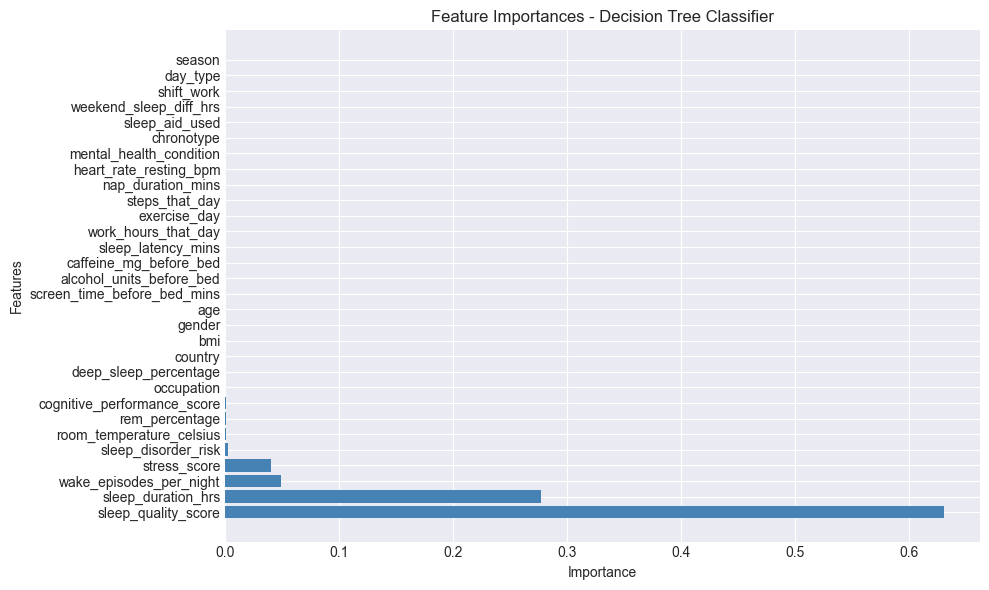

In [7]:
# Feature importances
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nWaznosc cech (Feature Importances):")
print(feature_importances)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['feature'], feature_importances['importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importances - Decision Tree Classifier')
plt.tight_layout()
plt.show()


## PREDYKCJE I OCENA MODELU

In [8]:
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print(f"\nAccuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 Score:    {f1:.4f}")


Accuracy:    0.7338
Precision:   0.7326
Recall:      0.7338
F1 Score:    0.7331


In [9]:
target_names = [str(i) for i in sorted(np.unique(y_test))]

print(classification_report(y_test, y_test_pred, target_names=target_names))

              precision    recall  f1-score   support

           0       0.78      0.79      0.78     12201
           1       0.66      0.65      0.65      7799

    accuracy                           0.73     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.73      0.73      0.73     20000



## Macierz pomyłek

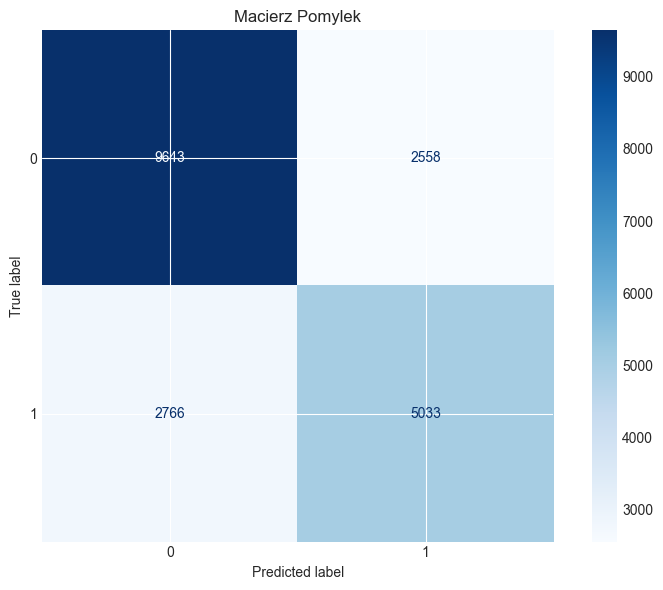

In [10]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, cmap='Blues')
ax.set_title('Macierz Pomylek')
plt.tight_layout()
plt.show()

In [11]:
precision_per_class = precision_score(y_test, y_test_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_test, y_test_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_test, y_test_pred, average=None, zero_division=0)

for i, class_name in enumerate(target_names):
    print(f"\nKlasa: {class_name}")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall:    {recall_per_class[i]:.4f}")
    print(f"  F1 Score:  {f1_per_class[i]:.4f}")


Klasa: 0
  Precision: 0.7771
  Recall:    0.7903
  F1 Score:  0.7837

Klasa: 1
  Precision: 0.6630
  Recall:    0.6453
  F1 Score:  0.6541


## Porownanie metryk na zbiorze treningowym vs testowym

In [12]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n{'Metryka':<20} {'Train':<15} {'Test':<15} {'Roznica':<15}")
print("-" * 60)
print(f"{'Accuracy':<20} {train_accuracy:<15.4f} {test_accuracy:<15.4f} {train_accuracy - test_accuracy:<15.4f}")
print(f"{'F1 Score':<20} {train_f1:<15.4f} {test_f1:<15.4f} {train_f1 - test_f1:<15.4f}")


Metryka              Train           Test            Roznica        
------------------------------------------------------------
Accuracy             0.7338          0.7338          0.0000         
F1 Score             0.7339          0.7331          0.0007         


## WIZUALIZACJA DRZEWA DECYZYJNEGO


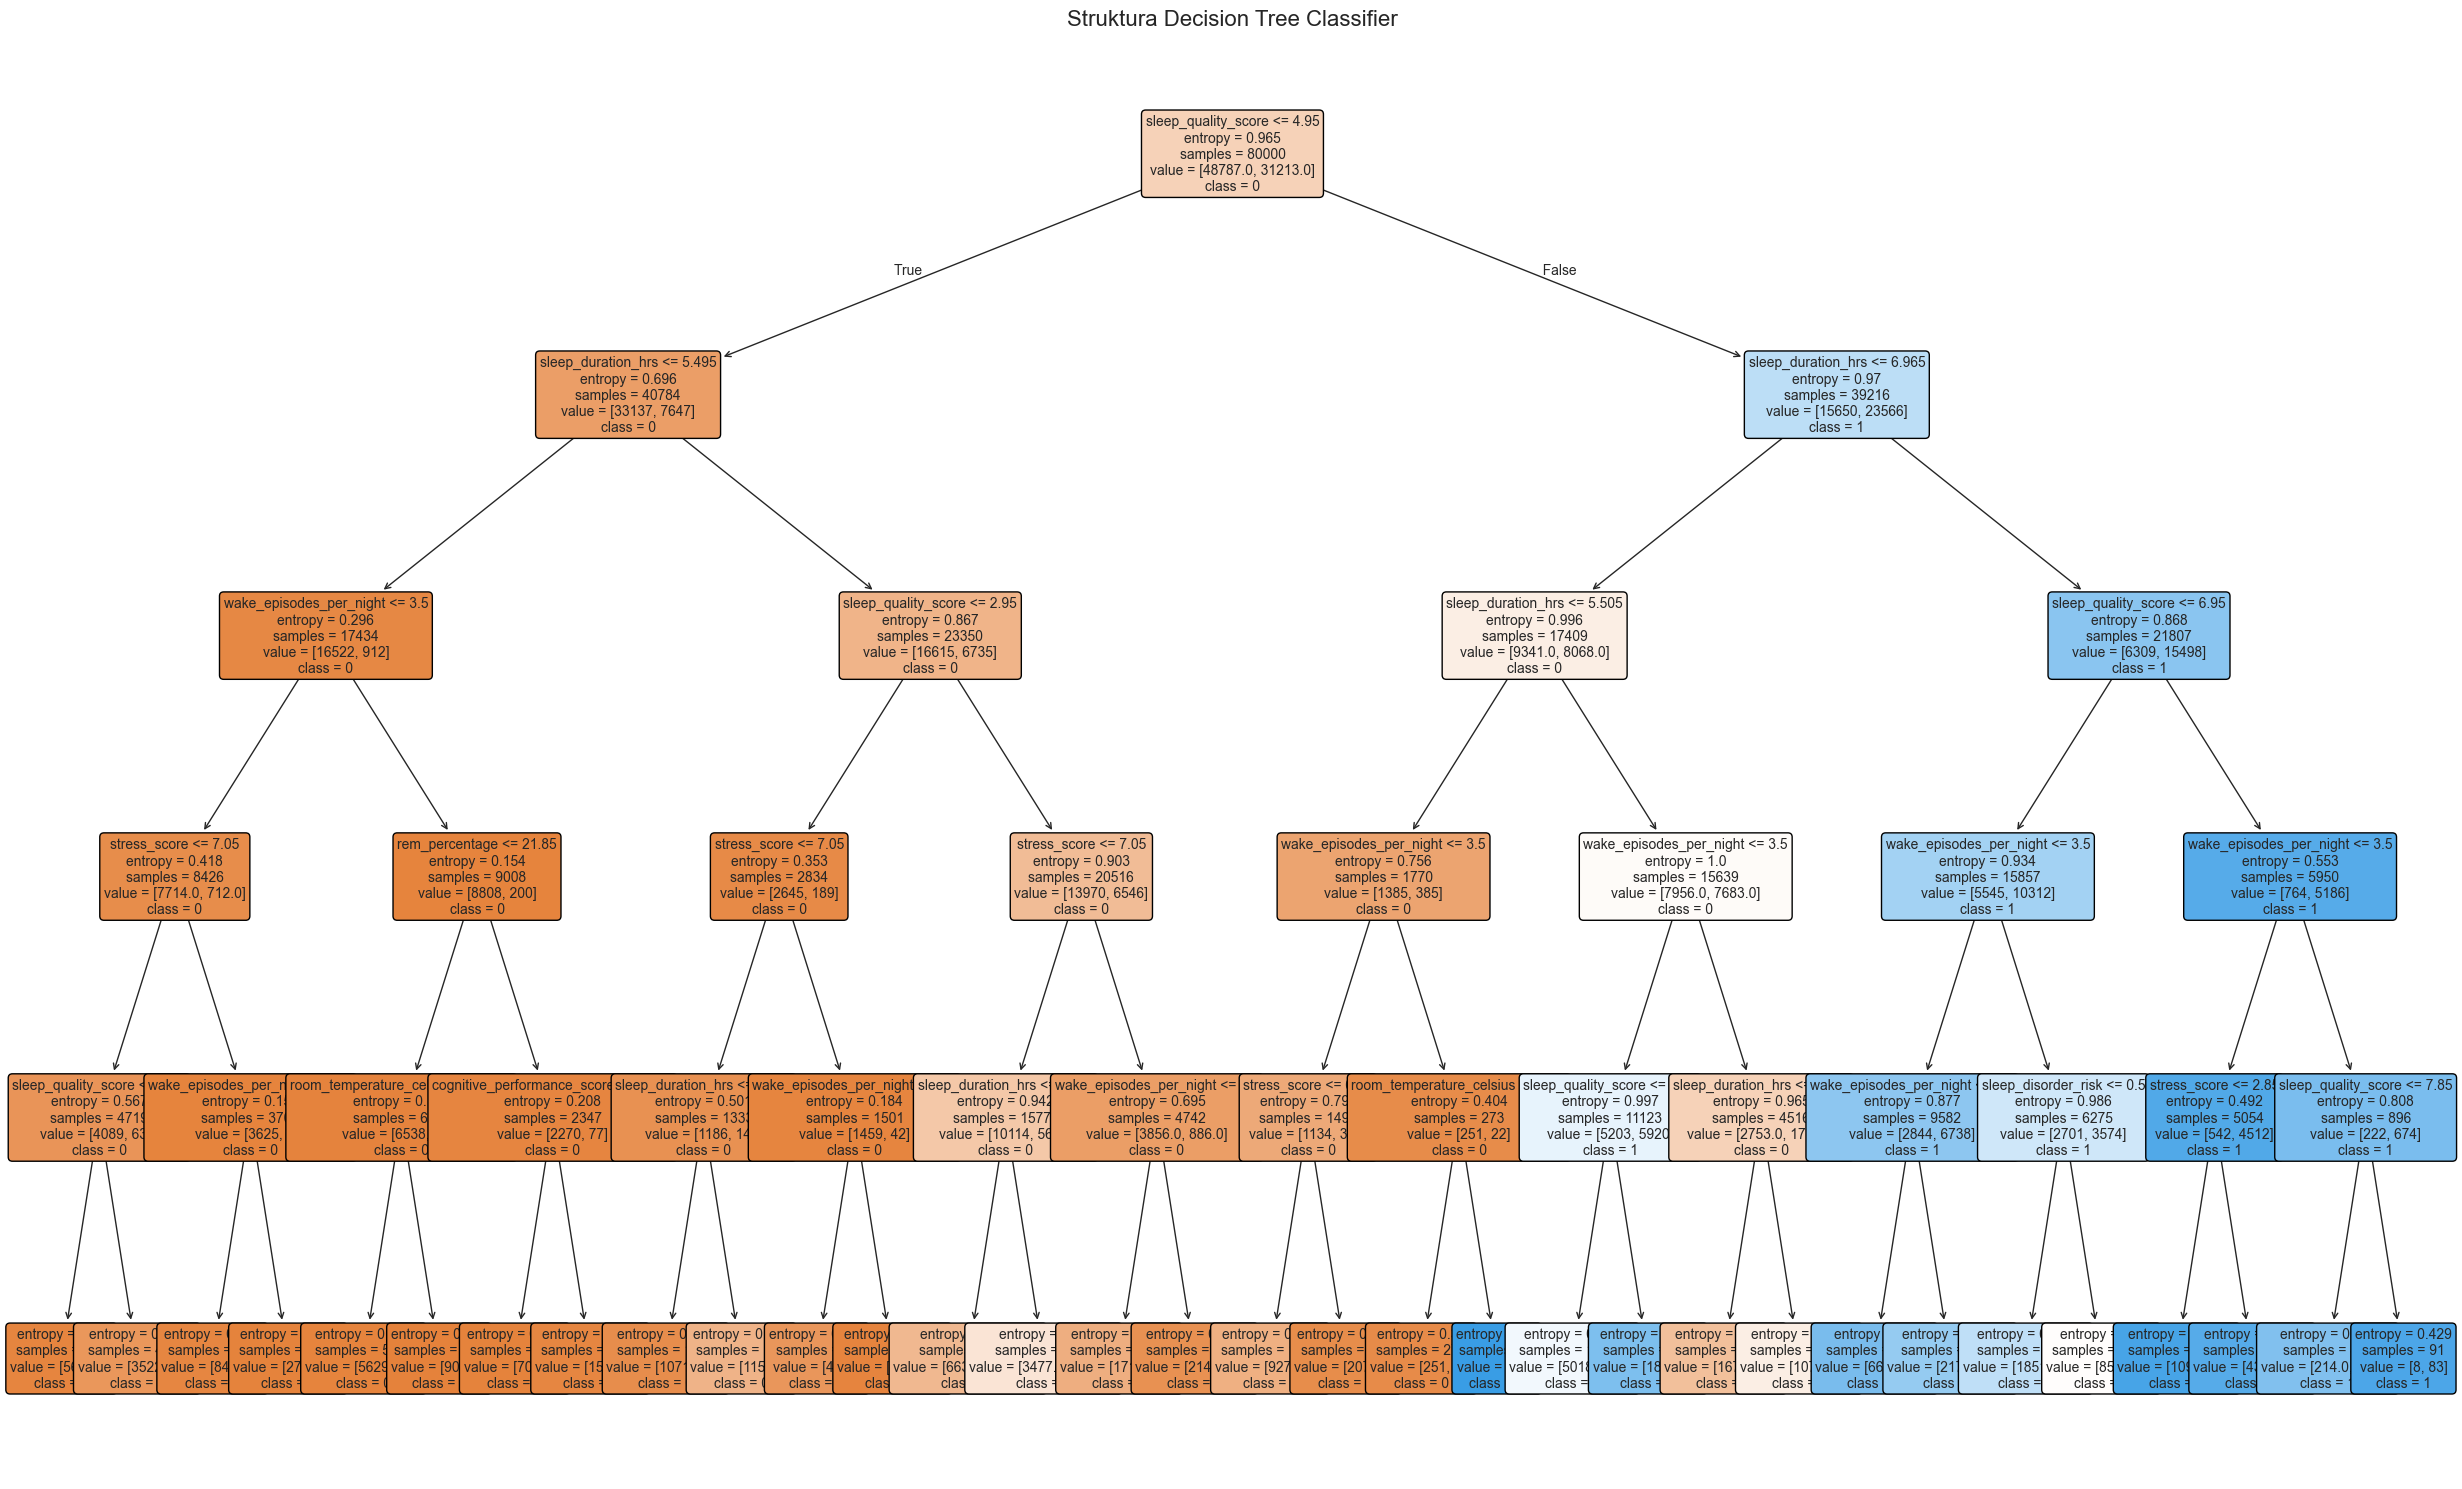

In [13]:
plt.figure(figsize=(25, 15))
plot_tree(dt_classifier,
          feature_names=X_train.columns.tolist(),
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Struktura Decision Tree Classifier', fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
tree_rules = export_text(dt_classifier, feature_names=X_train.columns.tolist())
print(tree_rules)

|--- sleep_quality_score <= 4.95
|   |--- sleep_duration_hrs <= 5.49
|   |   |--- wake_episodes_per_night <= 3.50
|   |   |   |--- stress_score <= 7.05
|   |   |   |   |--- sleep_quality_score <= 2.95
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- sleep_quality_score >  2.95
|   |   |   |   |   |--- class: 0
|   |   |   |--- stress_score >  7.05
|   |   |   |   |--- wake_episodes_per_night <= 1.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- wake_episodes_per_night >  1.50
|   |   |   |   |   |--- class: 0
|   |   |--- wake_episodes_per_night >  3.50
|   |   |   |--- rem_percentage <= 21.85
|   |   |   |   |--- room_temperature_celsius <= 23.85
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- room_temperature_celsius >  23.85
|   |   |   |   |   |--- class: 0
|   |   |   |--- rem_percentage >  21.85
|   |   |   |   |--- cognitive_performance_score <= 36.05
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- cognitive_performance_score >  36.05
|   |   |   |  

## PORÓWNANIE Z LISTĄ 1

In [15]:
print("if quality > 5.45: \n\tif duration < 5.5: \n\t\treturn 0 \n\tif stress > 7.0:\n\t\treturn 0\n\tif latency > 40:\n\t\treturn 0\n\tif (not is_mental_healthy) and stress > 5.5:\n\t\treturn 0\n\tif is_weekday and wakes > 4:\n\t\treturn 0\n\tif is_evening and duration < 6.5:\n\t\treturn 0\n\treturn 1\nelse:\n\tif duration < \n\t\treturn 0\n\tif is_weekday and wakes > 5:\n\t\treturn 0\n\treturn 1")

if quality > 5.45: 
	if duration < 5.5: 
		return 0 
	if stress > 7.0:
		return 0
	if latency > 40:
		return 0
	if (not is_mental_healthy) and stress > 5.5:
		return 0
	if is_weekday and wakes > 4:
		return 0
	if is_evening and duration < 6.5:
		return 0
	return 1
else:
	if duration < 
		return 0
	if is_weekday and wakes > 5:
		return 0
	return 1


## OBLICZENIE ENTROPII I INFORMATION GAIN
# Implementacja od zera w NumPy oraz weryfikacja feature_importances_


In [16]:
def entropy(y):
    y = np.asarray(y)
    if y.size == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()

    # dodaje 10^-12, aby uniknąć log(0)
    return -np.sum(probs * np.log2(probs + 1e-12))

def information_gain(parent_y, left_y, right_y):
    n = len(parent_y)
    if n == 0:
        return 0.0
    n_left = len(left_y)
    n_right = len(right_y)
    if n_left == 0 or n_right == 0:
        return 0.0

    h_parent = entropy(parent_y)
    h_left = entropy(left_y)
    h_right = entropy(right_y)

    ig = h_parent - (n_left / n) * h_left - (n_right / n) * h_right
    return ig

In [17]:
tree = dt_classifier.tree_
node_count = tree.node_count
feature_indices = tree.feature  # -2 dla liści, >=0 dla węzłów
thresholds = tree.threshold
n_node_samples = tree.n_node_samples
total_samples = n_node_samples[0]

# Pobrać ścieżkę decyzji dla każdej próbki treningowej
decision_path = dt_classifier.decision_path(X_train)
decision_path_arr = decision_path.toarray()

feature_importance_manual = {feat: 0.0 for feat in X_train.columns}

for node_id in range(node_count):
    feature_id = feature_indices[node_id]

    if feature_id < 0:
        continue

    feature_name = X_train.columns[feature_id]

    samples_at_node = np.where(decision_path_arr[:, node_id])[0]

    if len(samples_at_node) == 0:
        continue

    parent_y = np.array(y_train)[samples_at_node]

    # Pobrać próg podziału
    threshold = thresholds[node_id]

    # Wykonać podział
    feature_values = X_train.iloc[samples_at_node, feature_id].values
    left_mask = feature_values <= threshold
    left_y, right_y = parent_y[left_mask], parent_y[~left_mask]

    ig_node = information_gain(parent_y, left_y, right_y)

    # Obliczyć ważony wkład (weighted impurity decrease)
    weight = len(samples_at_node) / total_samples
    weighted_ig = weight * ig_node

    feature_importance_manual[feature_name] += weighted_ig

comparison_df = pd.DataFrame({
    'Feature': list(X_train.columns),
    'sklearn_importance': dt_classifier.feature_importances_,
    'manual_importance': [feature_importance_manual[f] for f in X_train.columns]
})
comparison_df = comparison_df.sort_values('sklearn_importance', ascending=False)

print("\nPorównanie importances sklearn vs. ręczne obliczenie:\n")
print(comparison_df.to_string(index=False))
print("\nRóżnica bezwzględna:")
comparison_df['difference'] = abs(comparison_df['sklearn_importance'] - comparison_df['manual_importance'])
print(comparison_df[['Feature', 'difference']].to_string(index=False))



Porównanie importances sklearn vs. ręczne obliczenie:

                    Feature  sklearn_importance  manual_importance
        sleep_quality_score            0.631041           0.155628
         sleep_duration_hrs            0.276701           0.068240
    wake_episodes_per_night            0.048881           0.012055
               stress_score            0.039903           0.009841
        sleep_disorder_risk            0.001830           0.000451
   room_temperature_celsius            0.000686           0.000169
             rem_percentage            0.000554           0.000137
cognitive_performance_score            0.000405           0.000100
                 occupation            0.000000           0.000000
      deep_sleep_percentage            0.000000           0.000000
                    country            0.000000           0.000000
                        bmi            0.000000           0.000000
                     gender            0.000000           0.000000
      

## WYBÓR CECH DO ANALIZY

In [18]:
sorted_features = comparison_df.sort_values('sklearn_importance', ascending=False).reset_index(drop=True)
top_feature = sorted_features.loc[0, 'Feature']
top_importance = sorted_features.loc[0, 'sklearn_importance']

bottom_feature = top_feature # temp assigment
bottom_importance = top_importance

bottom_found = False
i = len(sorted_features) - 1
while not bottom_found:
    if sorted_features.loc[i, 'sklearn_importance'] != 0.0:
        bottom_feature = sorted_features.loc[i, 'Feature']
        bottom_importance = sorted_features.loc[i, 'sklearn_importance']
        bottom_found = True
    else:
        i -= 1

print(f"\nNajważniejsza cecha: '{top_feature}'  -  importance = {top_importance:.6f}")
print(f"Najmniej ważna cecha: '{bottom_feature}'  -  importance = {bottom_importance:.6f}")


Najważniejsza cecha: 'sleep_quality_score'  -  importance = 0.631041
Najmniej ważna cecha: 'cognitive_performance_score'  -  importance = 0.000405


## POBIERANIE PROGÓW PODZIAŁU DLA WYBRANYCH CECH
W przypadku gdy cecha nie występuje w drzewie, nie ma przypisanego progu, więc bierzemy wtedy medianę tej cechy z danych treningowych

In [19]:
def get_first_threshold_for_feature(feature_name, feature_indices, thresholds):
    col_index = list(X_train.columns).index(feature_name)
    nodes_using_feature = np.where(feature_indices == col_index)[0]

    if len(nodes_using_feature) == 0:
        return None, None

    first_node = nodes_using_feature[0]
    return thresholds[first_node], first_node

threshold_top, node_top = get_first_threshold_for_feature(top_feature, feature_indices, thresholds)
threshold_bottom, node_bottom = get_first_threshold_for_feature(bottom_feature, feature_indices, thresholds)

print(f"\nCecha '{top_feature}':")
if threshold_top is not None:
    print(f"  - Próg z drzewa (węzeł {node_top}): {threshold_top:.6f}")
else:
    threshold_top = X_train[top_feature].median()
    print(f"  - Użyto mediany: {threshold_top:.6f}")

print(f"\nCecha '{bottom_feature}':")
if threshold_bottom is not None:
    print(f"  - Próg z drzewa (węzeł {node_bottom}): {threshold_bottom:.6f}")
else:
    threshold_bottom = X_train[bottom_feature].median()
    print(f"  - Użyto mediany: {threshold_bottom:.6f}")


Cecha 'sleep_quality_score':
  - Próg z drzewa (węzeł 0): 4.950000

Cecha 'cognitive_performance_score':
  - Próg z drzewa (węzeł 14): 36.049999


## Porównanie podziału po najważniejszej i najmniej ważnej cesze

In [20]:
def analyze_global_split(feature_name, threshold, y_true):
    feature_values = X_train[feature_name].values
    parent_y = np.array(y_true)

    left_mask = feature_values <= threshold
    left_y, right_y = parent_y[left_mask], parent_y[~left_mask]

    n_left = len(left_y)
    n_right = len(right_y)
    n_total = len(parent_y)

    ig = information_gain(parent_y, left_y, right_y)

    return {
        'feature': feature_name,
        'threshold': threshold,
        'n_left': n_left,
        'n_right': n_right,
        'n_total': n_total,
        'left_proportion': n_left / n_total,
        'right_proportion': n_right / n_total,
        'entropy_parent': entropy(parent_y),
        'entropy_left': entropy(left_y),
        'entropy_right': entropy(right_y),
        'information_gain': ig
    }

split_top = analyze_global_split(top_feature, threshold_top, y_train)
split_bottom = analyze_global_split(bottom_feature, threshold_bottom, y_train)

ratio_ig = split_top['information_gain'] / split_bottom['information_gain'] if split_bottom['information_gain'] > 0 else float('inf')
ratio_importance = top_importance / bottom_importance if bottom_importance > 0 else float('inf')

print(f"\n{'Metryka':<25} {'Najlepsza cecha':<30} {'Najgorsza cecha':<30}")
print("-" * 85)
print(f"{'Nazwa cechy':<25} {split_top['feature']:<30} {split_bottom['feature']:<30}")
print(f"{'Próg podziału':<25} {split_top['threshold']:<30.6f} {split_bottom['threshold']:<30.6f}")
print(f"{'Lewe - ilość':<25} {split_top['n_left']:<30} {split_bottom['n_left']:<30}")
print(f"{'Prawe - ilość':<25} {split_top['n_right']:<30} {split_bottom['n_right']:<30}")
print(f"{'Lewe - proporcja':<25} {split_top['left_proportion']:<30.4f} {split_bottom['left_proportion']:<30.4f}")
print(f"{'Prawe - proporcja':<25} {split_top['right_proportion']:<30.4f} {split_bottom['right_proportion']:<30.4f}")
print(f"{'Entropia rodzica':<25} {split_top['entropy_parent']:<30.6f} {split_bottom['entropy_parent']:<30.6f}")
print(f"{'Entropia lewego':<25} {split_top['entropy_left']:<30.6f} {split_bottom['entropy_left']:<30.6f}")
print(f"{'Entropia prawego':<25} {split_top['entropy_right']:<30.6f} {split_bottom['entropy_right']:<30.6f}")
print(f"{'Information Gain':<25} {split_top['information_gain']:<30.6f} {split_bottom['information_gain']:<30.6f}")

print(f"\nStosunek Feature Importance:")
print(f"  TOP / BOTTOM = {top_importance:.6f} / {bottom_importance:.6f} = {ratio_importance:.2f}x")

print(f"\nStosunek Information Gain:")
print(f"  TOP / BOTTOM = {split_top['information_gain']:.6f} / {split_bottom['information_gain']:.6f} = {ratio_ig:.2f}x")



Metryka                   Najlepsza cecha                Najgorsza cecha               
-------------------------------------------------------------------------------------
Nazwa cechy               sleep_quality_score            cognitive_performance_score   
Próg podziału             4.950000                       36.049999                     
Lewe - ilość              40784                          12598                         
Prawe - ilość             39216                          67402                         
Lewe - proporcja          0.5098                         0.1575                        
Prawe - proporcja         0.4902                         0.8425                        
Entropia rodzica          0.964904                       0.964904                      
Entropia lewego           0.696212                       0.377121                      
Entropia prawego          0.970405                       0.992611                      
Information Gain          0.13428

# LINEAR REGRESSION - Problem Regresji
#### Przewidywanie zmiennej cognitive_performance_score na podstawie pozostałych cech metodą analityczną (Least Squares) i iteracyjną (Gradient Descent)


## PRZYGOTOWANIE DANYCH DO REGRESJI


In [21]:
target_reg = 'cognitive_performance_score'

y_reg = df_encoded[target_reg].values
X_reg = df_encoded.drop(columns=[target_reg])

print(f"Rozmiar danych do regresji: {X_reg.shape[0]} wierszy x {X_reg.shape[1]} kolumn")
print(f"\nZmienna docelowa: {target_reg}")
print(f"Zakres wartości: [{y_reg.min():.2f}, {y_reg.max():.2f}]")
print(f"Średnia: {y_reg.mean():.2f}, Std Dev: {y_reg.std():.2f}")

Rozmiar danych do regresji: 100000 wierszy x 30 kolumn

Zmienna docelowa: cognitive_performance_score
Zakres wartości: [0.00, 100.00]
Średnia: 59.23, Std Dev: 22.25


## PREPROCESSING DANYCH DO REGRESJI
#### Podział danych według zmiennej `cognitive_performance_score`


In [22]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=32
)

## REGRESJA LINIOWA DLA NIE USTANDARYZOWANYCH DANYCH

In [23]:
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_reg, y_train_reg)

intercept_sklearn_unscaled = model_sklearn.intercept_
coef_sklearn_unscaled = model_sklearn.coef_

print(f"Intercept: {intercept_sklearn_unscaled:.6f}")
print(f"Wagi: {coef_sklearn_unscaled[:].round(5)}")

Intercept: -33.982846
Wagi: [ 0.01508 -0.04332  0.04263  0.17485  0.00396  1.66834  8.26124  1.09915
  0.63988  0.1233   0.41177 -0.00976 -2.10279  0.00285  7.95058 -0.00001
 -0.0033  -0.75439  0.07694 -0.11433  0.54784  0.0011   0.16603 -2.79189
  0.02574 -0.00672  0.01846  3.13815 -5.05483  0.58186]


## STANDARYZACJA DANYCH

In [24]:
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.fit_transform(X_test_reg)

# X_train_reg_scaled = X_train_reg
# X_test_reg_scaled = X_test_reg

scaled_df = pd.DataFrame(X_train_reg_scaled, columns=X_train_reg.columns)

print(f"\nPo standaryzacji:")
scaled_df.describe().round(3)


Po standaryzacji:


,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,sleep_disorder_risk,felt_rested
count,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,...,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.00
mean,0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,...,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.00
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.00
min,-1.512,-0.963,-1.739,-2.298,-1.586,-2.683,-2.570,-3.000,-3.591,-2.480,...,-2.112,-2.990,-1.131,-0.305,-1.909,-2.795,-1.344,-0.632,-0.775,-0.80
25%,-0.788,-0.963,-0.885,-0.689,-0.732,-0.700,-0.711,-0.655,-0.673,-0.767,...,-0.313,-0.633,-1.131,-0.305,-0.702,-0.674,-0.447,-0.632,-0.775,-0.80
50%,-0.155,-0.963,-0.031,0.004,-0.092,-0.050,0.020,0.019,0.009,-0.108,...,0.587,0.060,0.884,-0.305,-0.012,-0.000,-0.447,-0.632,-0.775,-0.80
75%,0.660,0.896,0.824,0.675,1.189,0.664,0.750,0.693,0.692,0.682,...,0.587,0.614,0.884,-0.305,0.677,0.686,0.449,1.582,0.470,1.25
max,3.103,2.755,1.393,4.183,1.403,3.195,3.406,2.862,2.292,5.031,...,0.587,4.218,0.884,3.275,2.574,2.287,1.346,1.582,2.962,1.25


## METODA 1: ROZWIĄZANIE ANALITYCZNE (LEAST SQUARES)


In [25]:
def fit_linear_regression_analytical(X, y):
    n_samples, n_features = X.shape

    # Dodaj kolumnę jedynek dla intercept
    X_with_bias = np.column_stack([np.ones(n_samples), X])

    # Oblicz macierz pseudoodwrotną
    # w = inv(X^T X) @ X^T @ y
    XtX = X_with_bias.T @ X_with_bias
    XtX_inv = np.linalg.inv(XtX)
    Xty = X_with_bias.T @ y

    w = XtX_inv @ Xty

    return w  # w[0] to bias, w[1:] to coefficients

def predict_linear(X, w):
    """Przyjmuje wartości X i wagi w tych wartości"""
    n_samples = X.shape[0]
    X_with_bias = np.column_stack([np.ones(n_samples), X])
    return X_with_bias @ w

In [26]:
print("Trenowanie modelu - metoda analityczna")
w_analytical = fit_linear_regression_analytical(X_train_reg_scaled, y_train_reg)

intercept_analytical = w_analytical[0]
coef_analytical = w_analytical[1:]

print(f"Intercept: {intercept_analytical:.6f}")
print(f"Wagi: {coef_analytical[:].round(5)}")

Trenowanie modelu - metoda analityczna
Intercept: 59.220159
Wagi: [ 0.16671 -0.0233   0.14971  0.7824   0.01855  2.12872 12.44128  3.7505
  2.71927  0.93565  0.79021 -0.6773  -2.21914  0.12686  3.95626 -0.03797
 -0.07057 -1.22267  0.26796 -0.0974   0.60897  0.0079   0.08239 -0.7798
  0.07466 -0.00529  0.02059  1.4175  -4.05797  0.28381]


In [27]:
y_train_pred_analytical = predict_linear(X_train_reg_scaled, w_analytical)
y_test_pred_analytical = predict_linear(X_test_reg_scaled, w_analytical)

mse_train_analytical = mse(y_train_reg, y_train_pred_analytical)
mse_test_analytical = mse(y_test_reg, y_test_pred_analytical)
mae_train_analytical = mae(y_train_reg, y_train_pred_analytical)
mae_test_analytical = mae(y_test_reg, y_test_pred_analytical)

print(f"\nMetoda Analityczna:")
print(f"  Train MSE: {mse_train_analytical:.6f},  MAE: {mae_train_analytical:.6f}")
print(f"  Test MSE:  {mse_test_analytical:.6f},  MAE: {mae_test_analytical:.6f}")


Metoda Analityczna:
  Train MSE: 50.115163,  MAE: 5.600072
  Test MSE:  49.662122,  MAE: 5.564931


## METODA 2: GRADIENT DESCENT


In [28]:
def fit_linear_regression_gd(X, y, learning_rate=0.01, epochs=2000, verbose=False):
    n_samples, n_features = X.shape

    w = np.zeros(n_features + 1)

    # Dodaj bias do X
    X_with_bias = np.column_stack([np.ones(n_samples), X])

    history_loss = []

    for epoch in range(epochs):
        y_pred = X_with_bias @ w
        error = y_pred - y

        gradient = (2.0 / n_samples) * (X_with_bias.T @ error)

        w = w - learning_rate * gradient
        loss = mse(y, y_pred)
        history_loss.append(loss)

        if verbose and (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}: MSE = {loss:.6f}")

    return w, history_loss

print("Trenowanie modelu - Gradient Descent")

learning_rates = [0.001, 0.01, 0.1]
gd_results = {}

for lr in learning_rates:
    print(f"Learning rate = {lr}")
    w_gd, history = fit_linear_regression_gd(
        X_train_reg_scaled, y_train_reg,
        learning_rate=lr, epochs=2000, verbose=False
    )
    gd_results[lr] = {"w": w_gd, "history": history}

    y_train_pred_gd = predict_linear(X_train_reg_scaled, w_gd)
    mse_train_gd = mse(y_train_reg, y_train_pred_gd)
    print(f"  Final Train MSE: {mse_train_gd:.6f}\n")

# Wybierz najlepszy learning rate (najniższe MSE)
best_lr = min(gd_results.keys(),
              key=lambda lr: gd_results[lr]["history"][-1])
w_gradient_descent = gd_results[best_lr]["w"]

print(f"Wybrany learning rate: {best_lr}")

intercept_gd = w_gradient_descent[0]
coef_gd = w_gradient_descent[1:]

print(f"Intercept: {intercept_gd:.6f}")
print(f"Wagi (pierwsze 5): {coef_gd[:].round(5)}")

Trenowanie modelu - Gradient Descent
Learning rate = 0.001
  Final Train MSE: 54.528234

Learning rate = 0.01
  Final Train MSE: 50.115172

Learning rate = 0.1
  Final Train MSE: 50.115163

Wybrany learning rate: 0.1
Intercept: 59.220159
Wagi (pierwsze 5): [ 0.16671 -0.0233   0.14971  0.7824   0.01855  2.12872 12.44128  3.7505
  2.71927  0.93565  0.79021 -0.6773  -2.21914  0.12686  3.95626 -0.03797
 -0.07057 -1.22267  0.26796 -0.0974   0.60897  0.0079   0.08239 -0.7798
  0.07466 -0.00529  0.02059  1.4175  -4.05797  0.28381]


In [29]:
y_train_pred_gd = predict_linear(X_train_reg_scaled, w_gradient_descent)
y_test_pred_gd = predict_linear(X_test_reg_scaled, w_gradient_descent)

mse_train_gd = mse(y_train_reg, y_train_pred_gd)
mse_test_gd = mse(y_test_reg, y_test_pred_gd)
mae_train_gd = mae(y_train_reg, y_train_pred_gd)
mae_test_gd = mae(y_test_reg, y_test_pred_gd)

print(f"Gradient Descent (lr={best_lr}):")
print(f"  Train MSE: {mse_train_gd:.6f},  MAE: {mae_train_gd:.6f}")
print(f"  Test MSE:  {mse_test_gd:.6f},  MAE: {mae_test_gd:.6f}")


Gradient Descent (lr=0.1):
  Train MSE: 50.115163,  MAE: 5.600072
  Test MSE:  49.662122,  MAE: 5.564931


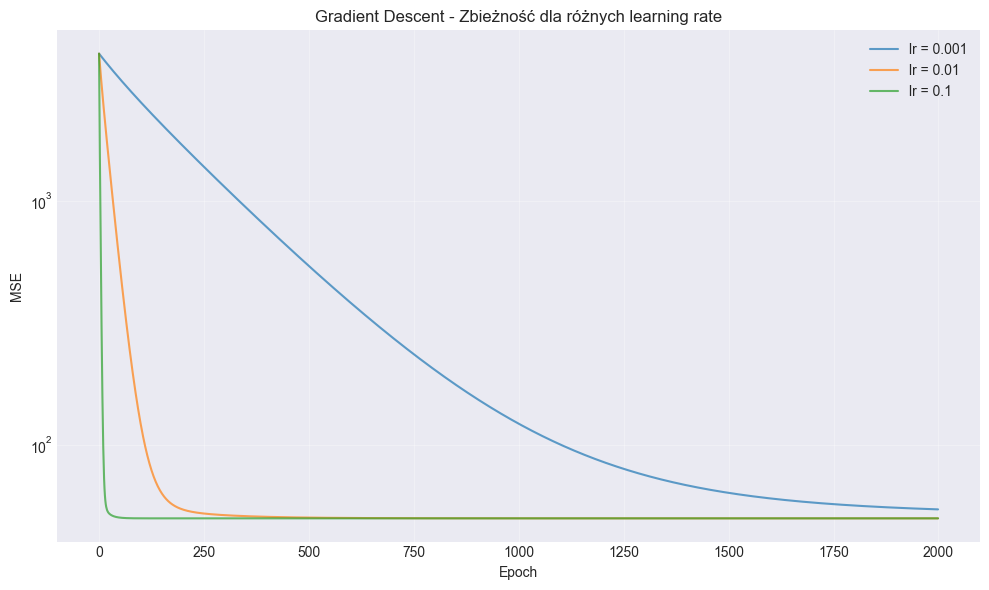

In [30]:
# Wizualizacja historii trenowania dla różnych learning rates
fig, ax = plt.subplots(figsize=(10, 6))

for lr in learning_rates:
    ax.plot(gd_results[lr]["history"], label=f"lr = {lr}", alpha=0.7)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Gradient Descent - Zbieżność dla różnych learning rate")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## METODA 3: SKLEARN LINEAR REGRESSION


In [31]:
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_reg_scaled, y_train_reg)

intercept_sklearn_scaled = model_sklearn.intercept_
coef_sklearn_scaled = model_sklearn.coef_

print(f"Intercept: {intercept_sklearn_scaled:.6f}")
print(f"Wagi: {coef_sklearn_scaled[:].round(5)}")

Intercept: 59.220159
Wagi: [ 0.16671 -0.0233   0.14971  0.7824   0.01855  2.12872 12.44128  3.7505
  2.71927  0.93565  0.79021 -0.6773  -2.21914  0.12686  3.95626 -0.03797
 -0.07057 -1.22267  0.26796 -0.0974   0.60897  0.0079   0.08239 -0.7798
  0.07466 -0.00529  0.02059  1.4175  -4.05797  0.28381]


In [32]:
y_train_pred_sklearn = model_sklearn.predict(X_train_reg_scaled)
y_test_pred_sklearn = model_sklearn.predict(X_test_reg_scaled)

mse_train_sklearn = mse(y_train_reg, y_train_pred_sklearn)
mse_test_sklearn = mse(y_test_reg, y_test_pred_sklearn)
mae_train_sklearn = mae(y_train_reg, y_train_pred_sklearn)
mae_test_sklearn = mae(y_test_reg, y_test_pred_sklearn)

print(f"Sklearn Linear Regression:")
print(f"  Train MSE: {mse_train_sklearn:.6f},  MAE: {mae_train_sklearn:.6f}")
print(f"  Test MSE:  {mse_test_sklearn:.6f},  MAE: {mae_test_sklearn:.6f}")

Sklearn Linear Regression:
  Train MSE: 50.115163,  MAE: 5.600072
  Test MSE:  49.662122,  MAE: 5.564931


## PORÓWNANIE WSZYSTKICH TRZECH METOD


In [33]:
comparison_results = pd.DataFrame({
    'Metoda': ['Analityczna - Least Squares', f'Gradient Descent (lr={best_lr})', 'Sklearn LinearRegression'],
    'Train MSE': [mse_train_analytical, mse_train_gd, mse_train_sklearn],
    'Test MSE': [mse_test_analytical, mse_test_gd, mse_test_sklearn],
    'Train MAE': [mae_train_analytical, mae_train_gd, mae_train_sklearn],
    'Test MAE': [mae_test_analytical, mae_test_gd, mae_test_sklearn]
})

print("\nPORÓWNANIE BŁĘDÓW NA ZBIORZE TESTOWYM:\n")
print(comparison_results.to_string(index=False))


PORÓWNANIE BŁĘDÓW NA ZBIORZE TESTOWYM:

                     Metoda  Train MSE  Test MSE  Train MAE  Test MAE
Analityczna - Least Squares  50.115163 49.662122   5.600072  5.564931
  Gradient Descent (lr=0.1)  50.115163 49.662122   5.600072  5.564931
   Sklearn LinearRegression  50.115163 49.662122   5.600072  5.564931


## PORÓWNANIE INTERCEPT


In [34]:
print(f"Analityczna:                   {intercept_analytical:.10f}")
print(f"Gradient Descent (lr={best_lr}):     {intercept_gd:.10f}")
print(f"Sklearn:                       {intercept_sklearn_scaled:.10f}")

print(f"\nRóżnica Sklearn vs GD:          {abs(intercept_sklearn_scaled - intercept_gd):.2e}")
print(f"Różnica Sklearn vs Analityczna: {abs(intercept_sklearn_scaled - intercept_analytical):.2e}")
print(f"Różnica GD vs Analityczna:      {abs(intercept_gd - intercept_analytical):.2e}")

Analityczna:                   59.2201587500
Gradient Descent (lr=0.1):     59.2201587500
Sklearn:                       59.2201587500

Różnica Sklearn vs GD:          7.11e-15
Różnica Sklearn vs Analityczna: 7.11e-15
Różnica GD vs Analityczna:      1.42e-14


## PORÓWNANIE WAG (COEFFICIENTS)

In [35]:
print(f"{'Cecha':<30} {'Analityczna':<20} {'Gradient Descent':<20} {'Sklearn':<20}")
print("-" * 90)

feature_names = X_train_reg.columns.tolist()
for i in range(min(10, len(feature_names))):
    print(f"{feature_names[i]:<30} {coef_analytical[i]:<20.10f} {coef_gd[i]:<20.10f} {coef_sklearn_scaled[i]:<20.10f}")


Cecha                          Analityczna          Gradient Descent     Sklearn             
------------------------------------------------------------------------------------------
age                            0.1667086457         0.1667086457         0.1667086457        
gender                         -0.0233040399        -0.0233040399        -0.0233040399       
occupation                     0.1497077608         0.1497077608         0.1497077608        
bmi                            0.7823950368         0.7823950368         0.7823950368        
country                        0.0185505944         0.0185505944         0.0185505944        
sleep_duration_hrs             2.1287246162         2.1287246162         2.1287246162        
sleep_quality_score            12.4412825860        12.4412825860        12.4412825860       
rem_percentage                 3.7505002306         3.7505002306         3.7505002306        
deep_sleep_percentage          2.7192688178         2.719268817

In [36]:
diff_gd_analytical = np.abs(coef_gd - coef_analytical)
diff_sklearn_analytical = np.abs(coef_sklearn_scaled - coef_analytical)
diff_gd_sklearn = np.abs(coef_gd - coef_sklearn_scaled)

print(f"\nŚrednie absolutne różnice:")
print(f"GD vs Analityczna:    {diff_gd_analytical.mean():.2e}")
print(f"Sklearn vs Analityczna: {diff_sklearn_analytical.mean():.2e}")
print(f"GD vs Sklearn:        {diff_gd_sklearn.mean():.2e}")


Średnie absolutne różnice:
GD vs Analityczna:    5.12e-15
Sklearn vs Analityczna: 9.00e-15
GD vs Sklearn:        5.88e-15


## WIZUALIZACJA PREDYKCJI NA ZBIORZE TESTOWYM


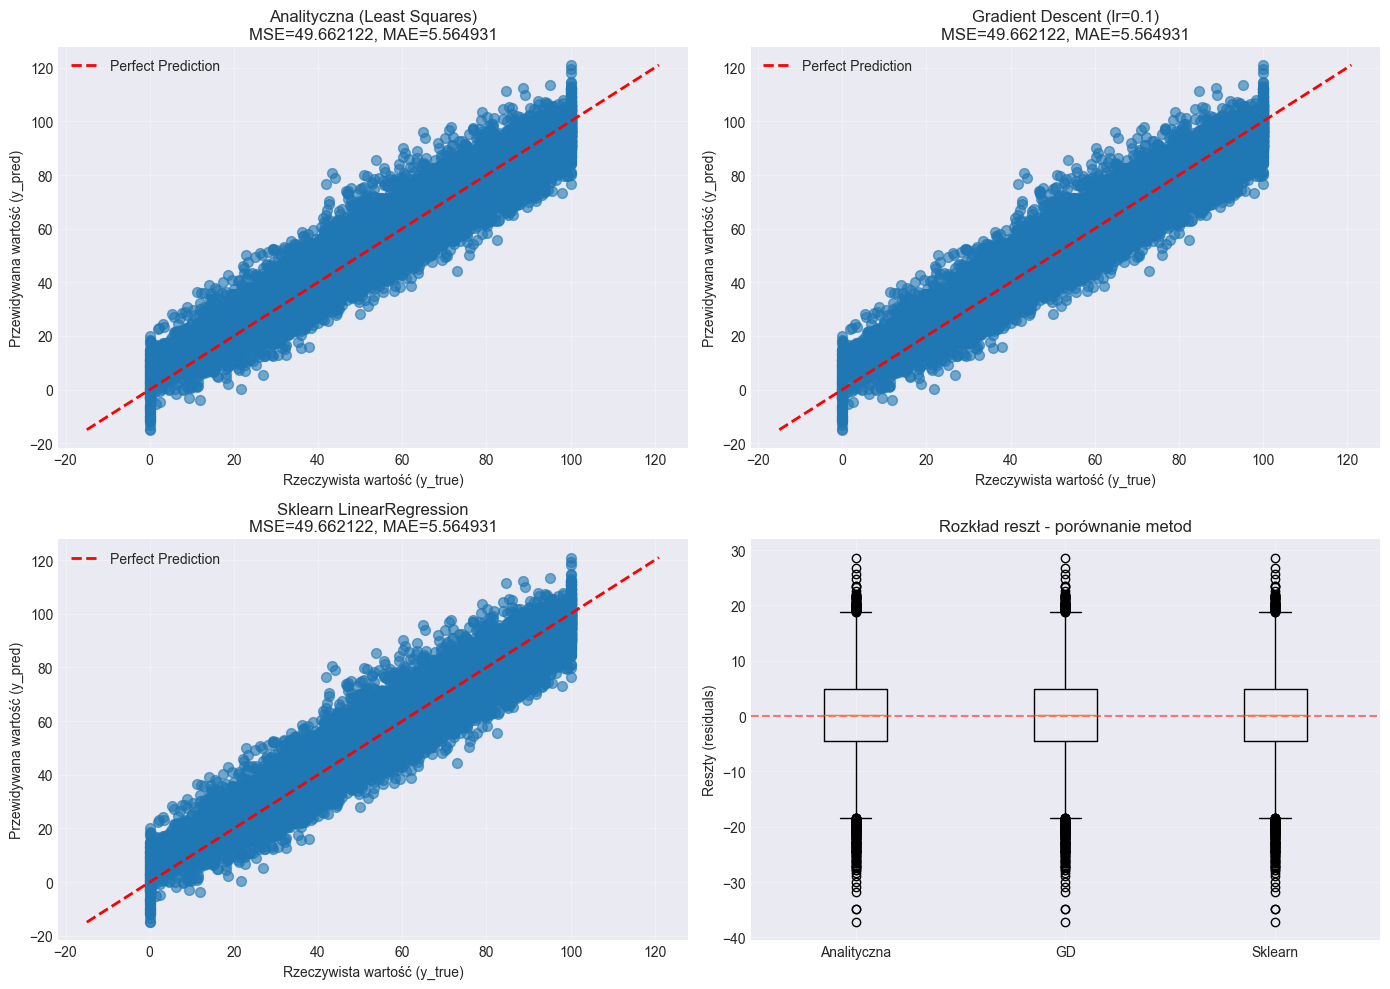

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = [
    ("Analityczna (Least Squares)", y_test_pred_analytical),
    (f"Gradient Descent (lr={best_lr})", y_test_pred_gd),
    ("Sklearn LinearRegression", y_test_pred_sklearn)
]

for idx, (method_name, y_pred) in enumerate(methods):
    ax = axes[idx // 2, idx % 2]

    ax.scatter(y_test_reg, y_pred, alpha=0.6, s=50)

    # Idealna prosta y=x
    min_val = min(y_test_reg.min(), y_pred.min())
    max_val = max(y_test_reg.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction', linewidth=2)

    test_mse = mse(y_test_reg, y_pred)
    test_mae = mae(y_test_reg, y_pred)

    ax.set_xlabel("Rzeczywista wartość (y_true)")
    ax.set_ylabel("Przewidywana wartość (y_pred)")
    ax.set_title(f"{method_name}\nMSE={test_mse:.6f}, MAE={test_mae:.6f}")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Czwarty subplot: porównanie reszt
ax = axes[1, 1]

residuals_analytical = y_test_reg - y_test_pred_analytical
residuals_gd = y_test_reg - y_test_pred_gd
residuals_sklearn = y_test_reg - y_test_pred_sklearn

ax.boxplot([residuals_analytical, residuals_gd, residuals_sklearn],
           tick_labels=['Analityczna', 'GD', 'Sklearn'])
ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_ylabel("Reszty (residuals)")
ax.set_title("Rozkład reszt - porównanie metod")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## PORÓWNANIE WAG REGRESJI MIĘDZY DANYMI PRZED I PO SKALOWANIU

In [38]:
print("\nWagi przed skalowaniem: ")
print(f"Intercept: {intercept_sklearn_unscaled:.6f}")
print(f"Wagi: {coef_sklearn_unscaled[:].round(5)}")

print("\nWagi po skalowaniu: ")
print(f"Intercept: {intercept_sklearn_scaled:.6f}")
print(f"Wagi: {coef_sklearn_scaled[:].round(5)}")



Wagi przed skalowaniem: 
Intercept: -33.982846
Wagi: [ 0.01508 -0.04332  0.04263  0.17485  0.00396  1.66834  8.26124  1.09915
  0.63988  0.1233   0.41177 -0.00976 -2.10279  0.00285  7.95058 -0.00001
 -0.0033  -0.75439  0.07694 -0.11433  0.54784  0.0011   0.16603 -2.79189
  0.02574 -0.00672  0.01846  3.13815 -5.05483  0.58186]

Wagi po skalowaniu: 
Intercept: 59.220159
Wagi: [ 0.16671 -0.0233   0.14971  0.7824   0.01855  2.12872 12.44128  3.7505
  2.71927  0.93565  0.79021 -0.6773  -2.21914  0.12686  3.95626 -0.03797
 -0.07057 -1.22267  0.26796 -0.0974   0.60897  0.0079   0.08239 -0.7798
  0.07466 -0.00529  0.02059  1.4175  -4.05797  0.28381]


## Wymuszanie skrajnych stanow (Underfitting vs Overfitting) - drzewo

In [39]:
def evaluate_tree_model(model, X_train_eval, y_train_eval, X_test_eval, y_test_eval):
    model.fit(X_train_eval, y_train_eval)
    y_train_pred_local = model.predict(X_train_eval)
    y_test_pred_local = model.predict(X_test_eval)

    return {
        "train_acc": accuracy_score(y_train_eval, y_train_pred_local),
        "test_acc": accuracy_score(y_test_eval, y_test_pred_local),
        "train_f1": f1_score(y_train_eval, y_train_pred_local, average='weighted', zero_division=0),
        "test_f1": f1_score(y_test_eval, y_test_pred_local, average='weighted', zero_division=0),
    }

tree_underfit = DecisionTreeClassifier(max_depth=1, random_state=13)
tree_overfit = DecisionTreeClassifier(max_depth=None, min_samples_split=2, random_state=13)
tree_reference = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=13,
    min_samples_split=10
)

metrics_underfit = evaluate_tree_model(tree_underfit, X_train, y_train, X_test, y_test)
metrics_overfit = evaluate_tree_model(tree_overfit, X_train, y_train, X_test, y_test)
metrics_reference = evaluate_tree_model(tree_reference, X_train, y_train, X_test, y_test)

tree_compare = pd.DataFrame([
    {"Model": "Underfitting (max_depth=1)", **metrics_underfit},
    {"Model": "Reference (max_depth=5)", **metrics_reference},
    {"Model": "Overfitting (max_depth=None)", **metrics_overfit},
])

print("\nPorownanie drzew decyzyjnych (under/overfitting):")
print(tree_compare.to_string(index=False))


Porownanie drzew decyzyjnych (under/overfitting):
                       Model  train_acc  test_acc  train_f1  test_f1
  Underfitting (max_depth=1)   0.708788    0.7103  0.712323 0.713784
     Reference (max_depth=5)   0.733838    0.7338  0.733861 0.733126
Overfitting (max_depth=None)   1.000000    0.6667  1.000000 0.666928


## Krzywa zlozonosci dla drzewa (Bias-Variance)

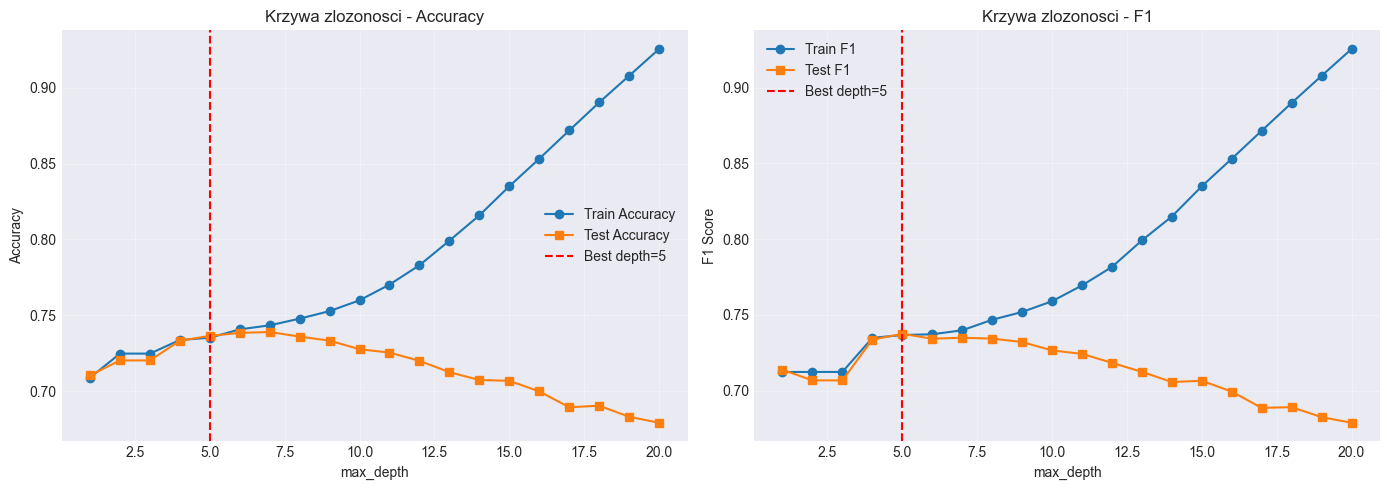

In [52]:
depth_values = range(1, 21)
train_acc_curve, test_acc_curve = [], []
train_f1_curve, test_f1_curve = [], []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=13)
    model.fit(X_train, y_train)
    y_train_pred_local = model.predict(X_train)
    y_test_pred_local = model.predict(X_test)

    train_acc_curve.append(accuracy_score(y_train, y_train_pred_local))
    test_acc_curve.append(accuracy_score(y_test, y_test_pred_local))
    train_f1_curve.append(f1_score(y_train, y_train_pred_local, average='weighted', zero_division=0))
    test_f1_curve.append(f1_score(y_test, y_test_pred_local, average='weighted', zero_division=0))

best_depth_idx = int(np.argmax(test_f1_curve))
best_depth = list(depth_values)[best_depth_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(depth_values, train_acc_curve, marker='o', label='Train Accuracy')
axes[0].plot(depth_values, test_acc_curve, marker='s', label='Test Accuracy')
axes[0].axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Krzywa zlozonosci - Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(depth_values, train_f1_curve, marker='o', label='Train F1')
axes[1].plot(depth_values, test_f1_curve, marker='s', label='Test F1')
axes[1].axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Krzywa zlozonosci - F1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Wymuszanie skrajnych stanow (Underfitting vs Overfitting) - regresja wielomianowa

In [53]:
feature_for_poly = X_train_reg.var().sort_values(ascending=False).index[0]
# feature_for_poly = 'sleep_quality_score'
feature_idx = list(X_train_reg.columns).index(feature_for_poly)

x_train_raw = X_train_reg[feature_for_poly].to_numpy().reshape(-1, 1)
x_test_raw = X_test_reg[feature_for_poly].to_numpy().reshape(-1, 1)

mean_feature = scaler_reg.mean_[feature_idx]
scale_feature = scaler_reg.scale_[feature_idx]

x_train = (x_train_raw - mean_feature) / scale_feature
x_test = (x_test_raw - mean_feature) / scale_feature

def fit_poly_regression(degree, x_train_local, y_train_local, x_test_local, y_test_local):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(x_train_local)
    X_test_poly = poly.transform(x_test_local)

    model = LinearRegression()
    model.fit(X_train_poly, y_train_local)

    y_train_pred_local = model.predict(X_train_poly)
    y_test_pred_local = model.predict(X_test_poly)

    return {
        "model": model,
        "poly": poly,
        "train_mse": mse(y_train_local, y_train_pred_local),
        "test_mse": mse(y_test_local, y_test_pred_local),
        "train_mae": mae(y_train_local, y_train_pred_local),
        "test_mae": mae(y_test_local, y_test_pred_local),
    }

poly_underfit = fit_poly_regression(1, x_train, y_train_reg, x_test, y_test_reg)
poly_overfit = fit_poly_regression(15, x_train, y_train_reg, x_test, y_test_reg)

poly_under_over = pd.DataFrame([
    {
        "Model": "Underfitting (degree=1)",
        "Train MSE": poly_underfit["train_mse"],
        "Test MSE": poly_underfit["test_mse"],
        "Train MAE": poly_underfit["train_mae"],
        "Test MAE": poly_underfit["test_mae"],
    },
    {
        "Model": "Overfitting (degree=15)",
        "Train MSE": poly_overfit["train_mse"],
        "Test MSE": poly_overfit["test_mse"],
        "Train MAE": poly_overfit["train_mae"],
        "Test MAE": poly_overfit["test_mae"],
    },
])

print("\nPorownanie regresji wielomianowej:")
print(f"Wybrana cecha: {feature_for_poly}")
print(poly_under_over.to_string(index=False))


Porownanie regresji wielomianowej:
Wybrana cecha: steps_that_day
                  Model  Train MSE   Test MSE  Train MAE  Test MAE
Underfitting (degree=1) 485.522857 487.997817  17.962500 18.029882
Overfitting (degree=15) 485.272269 487.680087  17.957697 18.021653


## Krzywa zlozonosci dla regresji wielomianowej (Bias-Variance)

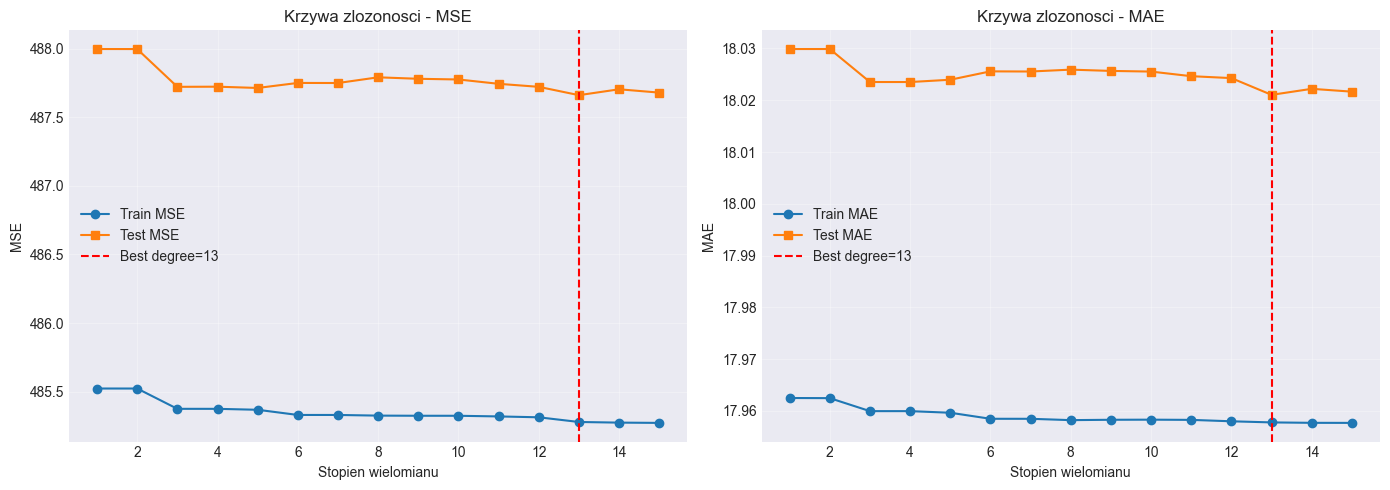

In [55]:
degree_values = range(1, 16)
train_mse_curve, test_mse_curve = [], []
train_mae_curve, test_mae_curve = [], []
poly_models = []

for degree in degree_values:
    result = fit_poly_regression(degree, x_train, y_train_reg, x_test, y_test_reg)
    train_mse_curve.append(result["train_mse"])
    test_mse_curve.append(result["test_mse"])
    train_mae_curve.append(result["train_mae"])
    test_mae_curve.append(result["test_mae"])
    poly_models.append(result)

best_degree_idx = int(np.argmin(test_mse_curve))
best_degree = list(degree_values)[best_degree_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(degree_values, train_mse_curve, marker='o', label='Train MSE')
axes[0].plot(degree_values, test_mse_curve, marker='s', label='Test MSE')
axes[0].axvline(best_degree, color='red', linestyle='--', label=f'Best degree={best_degree}')
axes[0].set_xlabel('Stopien wielomianu')
axes[0].set_ylabel('MSE')
axes[0].set_title('Krzywa zlozonosci - MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(degree_values, train_mae_curve, marker='o', label='Train MAE')
axes[1].plot(degree_values, test_mae_curve, marker='s', label='Test MAE')
axes[1].axvline(best_degree, color='red', linestyle='--', label=f'Best degree={best_degree}')
axes[1].set_xlabel('Stopien wielomianu')
axes[1].set_ylabel('MAE')
axes[1].set_title('Krzywa zlozonosci - MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Problem "Czarnego Labedzia" - ekstrapolacja dla regresji wielomianowej


Predykcje dla punktu anomalii (20% poza zakresem):
Underfitting (degree=1):  73.3539
Optimal (degree=13): 33781.1883
Overfitting (degree=15): 57812.0162


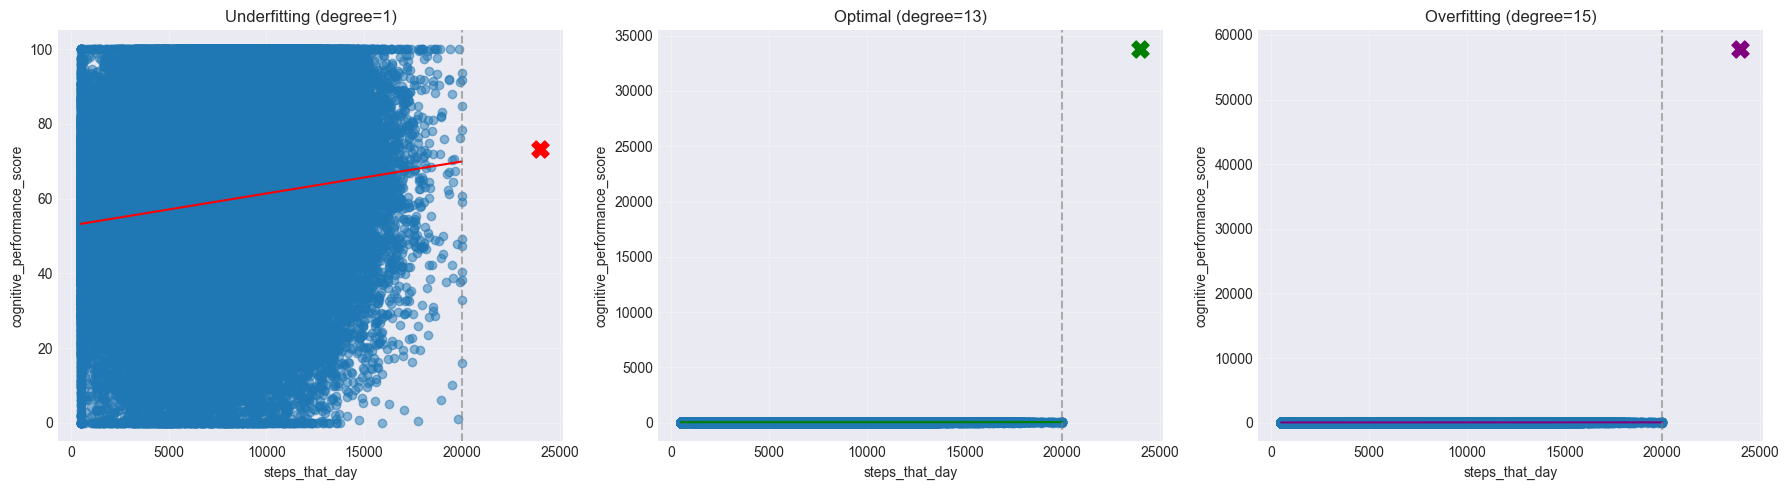

In [56]:
x_min_raw = x_train_raw.min()
x_max_raw = x_train_raw.max()
x_anomaly_raw = x_max_raw * 1.2

x_plot_raw = np.linspace(x_min_raw, x_max_raw, 200).reshape(-1, 1)
x_plot = (x_plot_raw - mean_feature) / scale_feature
x_anomaly = (np.array([[x_anomaly_raw]]) - mean_feature) / scale_feature

model_underfit = poly_models[0]
model_optimal = poly_models[best_degree_idx]
model_overfit = poly_models[14]

def predict_poly(model_bundle, x_values):
    X_poly = model_bundle["poly"].transform(x_values)
    return model_bundle["model"].predict(X_poly)

y_underfit_plot = predict_poly(model_underfit, x_plot)
y_optimal_plot = predict_poly(model_optimal, x_plot)
y_overfit_plot = predict_poly(model_overfit, x_plot)

y_underfit_anomaly = predict_poly(model_underfit, x_anomaly)[0]
y_optimal_anomaly = predict_poly(model_optimal, x_anomaly)[0]
y_overfit_anomaly = predict_poly(model_overfit, x_anomaly)[0]

print("\nPredykcje dla punktu anomalii (20% poza zakresem):")
print(f"Underfitting (degree=1):  {y_underfit_anomaly:.4f}")
print(f"Optimal (degree={best_degree}): {y_optimal_anomaly:.4f}")
print(f"Overfitting (degree=15): {y_overfit_anomaly:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(x_train_raw, y_train_reg, alpha=0.5)
axes[0].plot(x_plot_raw, y_underfit_plot, color='red')
axes[0].scatter([x_anomaly_raw], [y_underfit_anomaly], color='red', marker='X', s=150)
axes[0].axvline(x_max_raw, color='gray', linestyle='--', alpha=0.6)
axes[0].set_title('Underfitting (degree=1)')
axes[0].set_xlabel(feature_for_poly)
axes[0].set_ylabel('cognitive_performance_score')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(x_train_raw, y_train_reg, alpha=0.5)
axes[1].plot(x_plot_raw, y_optimal_plot, color='green')
axes[1].scatter([x_anomaly_raw], [y_optimal_anomaly], color='green', marker='X', s=150)
axes[1].axvline(x_max_raw, color='gray', linestyle='--', alpha=0.6)
axes[1].set_title(f'Optimal (degree={best_degree})')
axes[1].set_xlabel(feature_for_poly)
axes[1].set_ylabel('cognitive_performance_score')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(x_train_raw, y_train_reg, alpha=0.5)
axes[2].plot(x_plot_raw, y_overfit_plot, color='purple')
axes[2].scatter([x_anomaly_raw], [y_overfit_anomaly], color='purple', marker='X', s=150)
axes[2].axvline(x_max_raw, color='gray', linestyle='--', alpha=0.6)
axes[2].set_title('Overfitting (degree=15)')
axes[2].set_xlabel(feature_for_poly)
axes[2].set_ylabel('cognitive_performance_score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()